<a href="https://colab.research.google.com/github/marklinista-HO/Desafio_Telecom_X-Parte_2/blob/main/telecomx2_LAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##📌 EXTRACCIÓN

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#  Este parámetro de  Pandas es para que se puedan ver TODAS las columnas
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('/content/datos_tratados.csv')
df

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [4]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


##🛠️ Pre procesamiento

###✔️ Remover columnas irrelevantes

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Monthly`: total de todos los servicios del cliente por mes
- `Total`: total gastado por el cliente


In [6]:
#  Remover columna CustomerID
df = df.drop(columns=['CustomerID'])


In [7]:
#  Revisando
df.head(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.4


###Verificando valores únicos en cols.

In [8]:
#  Verificando valores únicos en las columnas:
for column in df.columns:
  #print(column)
  print(df[column].nunique(),' ', column)
  print(df[column].unique())
  print('---------------------------------')
  #{df[col].nunique()}'")

2   Churn
['No' 'Yes']
---------------------------------
2   Gender
['Female' 'Male']
---------------------------------
2   SeniorCitizen
['No' 'Yes']
---------------------------------
2   Partner
['Yes' 'No']
---------------------------------
2   Dependents
['Yes' 'No']
---------------------------------
73   Tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
---------------------------------
2   PhoneService
['Yes' 'No']
---------------------------------
2   MultipleLines
['No' 'Yes']
---------------------------------
3   InternetService
['DSL' 'Fiber optic' 'No']
---------------------------------
2   OnlineSecurity
['No' 'Yes']
---------------------------------
2   OnlineBackup
['Yes' 'No']
---------------------------------
2   DeviceProtection
['No' 'Yes']
---------------------------------
2   TechSupport


In [9]:
#  La respuesta 'No internet service'  NO  aporta,
#  por lo que la cambiamos sólo a  NO
#  Cols. en donde cambiar:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
#  Reemplazar por NO:
for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})


✔️ Verificación nuevamente de los valores nulos

In [10]:
#
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 📊 EDA  (Exploratory Data Analysis)

##🎯 Análisis dirigido

In [11]:
#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt
import plotly.express as px

###Distrib. meses contrato

In [12]:
px.histogram(df, x = 'Tenure', text_auto = True, color = 'Churn', barmode = 'group')

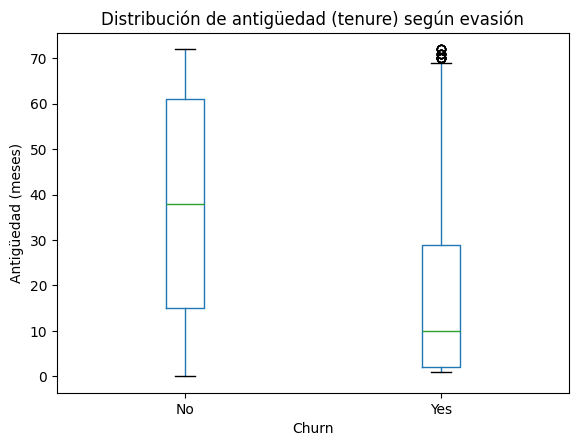

In [13]:
df.boxplot(column='Tenure', by='Churn', grid=False)
plt.title('Distribución de antigüedad (tenure) según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (meses)')
plt.show()

In [14]:
df.groupby('Churn')['Tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


####ALERTA: Momento de más cancelación
La mayor cancelación ocurre en los primeros meses de contrato.  Algo NO está gustando en los primeros meses.

Los clientes que abandonan el servicio tienden a presentar menor antigüedad. Esto sugiere que el churn ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

####OBSERVACION: Tiempo contrato
Los más viejos tienden a cancelar menos.

---
---



###Distrib. total gastado

In [15]:
df.sample()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
2350,No,Male,No,Yes,Yes,30,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,2.85,85.45,2509.95


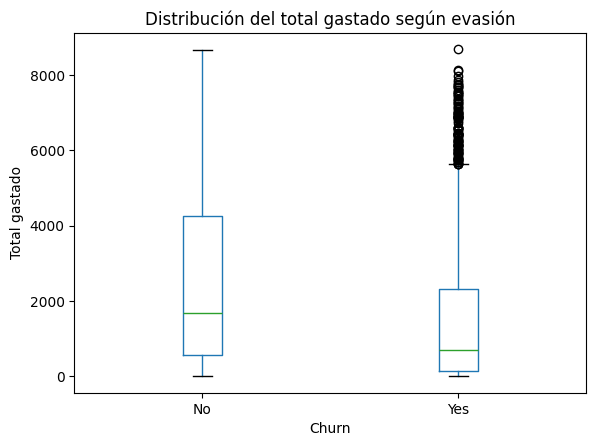

In [16]:
df.boxplot(column='ChargesTotal', by='Churn', grid=False)
plt.title('Distribución del total gastado según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

In [17]:
df.groupby('Churn')['ChargesTotal'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


El total gastado suele estar asociado a la antigüedad: clientes con menor tenure tienden a acumular menor gasto total y concentran mayor evasión.

Observaciones

tiempo_contrato: los clientes que cancelan suelen tener un tiempo de contrato mucho más corto.

valor_mensual: los clientes con facturas mensuales más altas son más propensos a cancelar.

total_cobrado: los clientes no han acumulado mucha facturación histórica antes de irse.

cuentas_diarias: los clientes con facturas mensuales más altas son más propensos a cancelar.

✔️ Correlación entre variables numericas

In [18]:
#  creando DF solo con vars numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])
df_numeric.sample(5)

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
6921,1,1.85,55.45,55.45
5538,18,2.28,68.35,1299.80
4604,6,0.69,20.65,109.30
1340,48,2.36,70.65,3545.05
3087,2,3.13,93.85,196.75


In [19]:
#  Agregando churn, pero convertila en numérica, mapeandola con 1 y 0
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df_numeric.sample(5)


,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn
426,65,3.12,93.55,6069.25,0
1162,46,3.04,91.30,4126.35,0
5155,10,2.85,85.60,813.85,1
6727,13,2.97,88.95,1161.75,0
3662,2,2.14,64.20,143.65,0


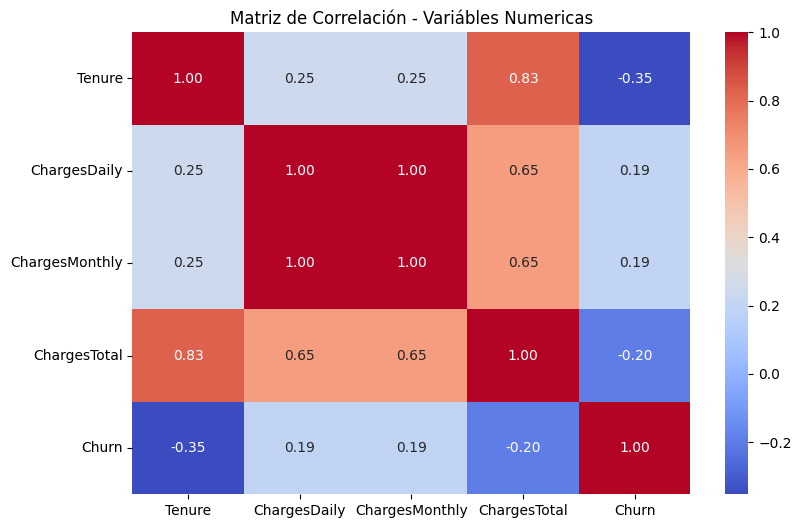

In [20]:
#  Ahora podemos calcular la matriz de corr con churn:
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(9,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


In [21]:
#  CharlesMonthly y ChargesDaily están perfectamente correlacionadas, una deriva de la otra
#  por lo que sólo necesitamos tener una:  botaremos del DF: "ChargesDaily"
#  Lo mismo con tenure y CharlesTotal, están bastante correlacionadas, una deriva de la otra
#  por lo que sólo necesitamos usar una:  botaremos del DF:  "ChargesTotal"
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

In [22]:
#  Comprobando:
df.sample(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
5810,No,Female,No,Yes,Yes,68,No,No,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),60.30
4011,No,Female,Yes,No,No,18,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic),49.85


2️⃣ Analisis de churn por categoria (variables categoricas)

🔹 Seleccionar variables categoricas

In [23]:
#  Hacer lista de cols categóricas:
categorical_cols = df.select_dtypes(include=["object"]).columns
#  Quitamos "Churn":
categorical_cols = categorical_cols.drop("Churn")
#
categorical_cols

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

🔹 Tabla de proporción de  'Churn'  por categoria

In [24]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    #  crea una tabla de porcentaje de 'churn' dentro de cada categoría
    #  de una variable:
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)
#  PERO si son muchas cols, no podemos hacer esto.


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


##🎯 Metodo recomendado: Qui-cuadrado (Chi-Square Test)

In [25]:
#
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia del DF
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporal (apenas para test estadístico)
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Crear DataFrame con ranking
#  Mientras más alto el "Chi2 Score", se tiene más asociación con el "Churn"
#  El  "p-value"  es como el margen de error.  Mientras más bajo, mas cierta es la info.
#  debe ser menor a 0.05
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [26]:
#  Buscamos las variables que tienen mas similitud con churn y que tenga el p-value < 0.05
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Al menos 'Gender' y 'PhoneService' seguro se pueden eliminar.

In [27]:
#  Remover columnas  Gender  y  PhoneService:
df = df.drop(columns=["Gender","PhoneService"])

In [28]:
df.sample(3)

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
2293,No,No,No,No,2,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.25
3619,No,No,No,No,1,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.80
830,Yes,No,No,No,6,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),49.65


##🎯 Encoding

###Transformación de datos

Variables explicativas y variable de respuesta

In [29]:
#  Queremos separar las variables explicativas y la vars. respuesta.
df.sample(3)


,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
5531,No,No,No,No,6,No,No,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),20.15
1684,Yes,Yes,Yes,No,12,Yes,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,98.10
348,No,No,Yes,Yes,28,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),100.35


In [30]:
#  X=vars explicativas
#  y=var respuesta o dependiente
X = df.drop('Churn', axis = 1)
y = df['Churn']


In [31]:
#
X

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [32]:
#
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


###Transformando 'X' las variables explicativas

Utilizamos el método de One Hot Encoder

In [33]:
#  Nos ayuda a generar un transformador de columnas:
from sklearn.compose import make_column_transformer
#  Este ayuda a hacer la transformación del One Hot Encoder:
from sklearn.preprocessing import OneHotEncoder


In [34]:
X.sample(2)

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
6465,No,No,No,56,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,52.70
1874,No,Yes,Yes,6,Yes,DSL,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),48.95


In [35]:
#  Creamos las columnas de las vars de X:
columnas = X.columns
columnas

Index(['SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly'],
      dtype='object')

In [36]:
# Columnas categóricas y numéricas
cols_categorical = X.select_dtypes(include=["object"]).columns
cols_numeric = X.select_dtypes(include=["int64", "float64"]).columns

cols_categorical, cols_numeric

(Index(['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['Tenure', 'ChargesMonthly'], dtype='object'))

In [37]:
#  Verificando valores únicos en las columnas:
for column in X.columns:
  print(df[column].nunique(),' ', column)
  print(X[column].unique())

2   SeniorCitizen
['No' 'Yes']
2   Partner
['Yes' 'No']
2   Dependents
['Yes' 'No']
73   Tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
2   MultipleLines
['No' 'Yes']
3   InternetService
['DSL' 'Fiber optic' 'No']
2   OnlineSecurity
['No' 'Yes']
2   OnlineBackup
['Yes' 'No']
2   DeviceProtection
['No' 'Yes']
2   TechSupport
['Yes' 'No']
2   StreamingTV
['Yes' 'No']
2   StreamingMovies
['No' 'Yes']
3   Contract
['One year' 'Month-to-month' 'Two year']
2   PaperlessBilling
['Yes' 'No']
4   PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
1585   ChargesMonthly
[65.6  59.9  73.9  ... 91.75 68.8  67.85]


In [38]:
#  Ahora a hacer nuestro modelo
#  drop = 'if_binary' :  ignorar los casos en que la col es binaria: 'default' y 'prestatario'
#  remainder = 'passthrough' :  que omita el restante de las cols.
#  sparse_threshold=0 : nos permite colocar y llenar de 0's la matriz
#  force_int_remainder_cols=False : que NO cambie el nombre de las cols.
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), cols_categorical),
#    ['estado_civil', 'escolaridad', 'default', 'prestatario']
#),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)


In [39]:
#  Ahora vamos a cambiar nuestra X y volverla one_hot
#  .fit_transform : ajusta nuestro modelo
#  colocamos en X toda nuestra transformación
X = one_hot.fit_transform(X)


In [40]:
#  Vamos a ver cómo quedaron las vars explicativas:
#  remainder__ :  las dejó igual
#  __si  :  son binarias y las pasó a 0 y 1
#  onehotencoder__ :  son las transformadas
one_hot.get_feature_names_out(columnas)


array(['onehotencoder__SeniorCitizen_Yes', 'onehotencoder__Partner_Yes',
       'onehotencoder__Dependents_Yes',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_Yes',
       'onehotencoder__StreamingMovies_Yes',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year',
       'onehotencoder__Contract_Two year',
       'onehotencoder__PaperlessBilling_Yes',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check', 'remainder__Tenure',
       'rema

In [41]:
#  Revisando X
X

array([[ 0.  ,  1.  ,  1.  , ...,  1.  ,  9.  , 65.6 ],
       [ 0.  ,  0.  ,  0.  , ...,  1.  ,  9.  , 59.9 ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  4.  , 73.9 ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  1.  ,  2.  , 50.3 ],
       [ 0.  ,  1.  ,  1.  , ...,  1.  , 67.  , 67.85],
       [ 0.  ,  1.  ,  1.  , ...,  0.  , 63.  , 59.  ]])

In [42]:
#  Para visualizar mejor, lo pasamos a DF
pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))


,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,onehotencoder__TechSupport_Yes,onehotencoder__StreamingTV_Yes,onehotencoder__StreamingMovies_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.60
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.90
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.90
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.00
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,55.15
7039,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,22.0,85.10
7040,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,50.30
7041,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,67.0,67.85


###Transformando 'y' la variable respuesta

In [43]:
#
from sklearn.preprocessing import LabelEncoder

In [44]:
#  Lo instanciamos:
label_encoder = LabelEncoder()

In [45]:
#  Le hacemos el fit_transform a  y  de este label_encoder
y = label_encoder.fit_transform(y)

In [46]:
#  Revisando  y :
y

array([0, 0, 1, ..., 0, 0, 0])

In [47]:
y.shape

(7043,)

**YA TENEMOS NUESTRA VARS. EN FORMATO NUMÉRICO para iniciar nuestro modelado.**

##🎯 Split train y test

In [48]:
#
from sklearn.model_selection import train_test_split

#  train_size  por default es 0.25, usamos 0.30
#  strarify = y :  se le dice que los datos de train y test sean lo "más parecidas"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y,  random_state = 5)


In [49]:
print('X_train ',X_train.shape)
print('y_train ',y_train.shape)
print('X_test ',X_test.shape)
print('y_test ',y_test.shape)

X_train  (4930, 23)
y_train  (4930,)
X_test  (2113, 23)
y_test  (2113,)


**Ya tenemos la separación de nuestra base de entrenamiento y la base de prueba.**

##🎯 Modelo Baseline - de referencia

In [50]:
#
from sklearn.dummy import DummyClassifier

In [51]:
#  Instanciamos nuestro modelo Dummy
dummy = DummyClassifier()
#  Mostrando base de entrenamiento para entrenarlo
dummy.fit(X_train, y_train)
#  Después de entrenarlo, vemos cómo se desempeñó:
#  con la base de la que NO aprendió(_test), la ponemos a prueba:
dummy.score(X_test, y_test)
#
#  Quiere decir que 73.45% de las veces, el modelo Dummy clasificó correctamente

0.73450070989115

##🎯 Verificar desbalanceamiento

In [52]:
df['Churn'].value_counts(normalize=True) * 100
#  Está levemente desbalanceado

,proportion
Churn,
No,73.463013
Yes,26.536987


##🎯 Árboles de Decisión

In [53]:
#
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [54]:
#  Con TODOS los niveles:
modelo_arbol = DecisionTreeClassifier(random_state =7)
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(random_state=7)

In [55]:
#
y_predict = modelo_arbol.predict(X_test)
y_predict

array([0, 1, 1, ..., 1, 0, 0])

In [56]:
print("Arbol de decisión")
print(classification_report(y_test, y_predict))
#  Da 73% de exactitud (accuracy).
#  También ver la precisión y recall, el yes está muy bajo.
#  Precision no es muy confiable por el recall muy bajo

Arbol de decisión
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1552
           1       0.49      0.50      0.49       561

    accuracy                           0.73      2113
   macro avg       0.65      0.65      0.65      2113
weighted avg       0.73      0.73      0.73      2113



In [57]:
#  con la base de la que NO aprendió(_test), la ponemos a prueba otra vez:
modelo_arbol.score(X_test, y_test)
#  Aparentemente NO mejoró mucho.

0.7274017983909133

In [58]:
#  Evaluando:
modelo_arbol.score(X_train, y_train)
#  Da casi 1.0 pues se aprendió cada una de las observaciones.  Cada rama se completó, GINI=0

0.9971602434077079

In [59]:
#  Vamos a recrear nuestro modelo de árbol,
#  y vamos a añadir un parámetro,    max_depth = 5  :  indica los niveles abajo de la raiz
modelo_arbol = DecisionTreeClassifier(max_depth = 5, random_state =7)
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=7)

In [60]:
#
y_predict = modelo_arbol.predict(X_test)
y_predict

array([0, 1, 1, ..., 1, 0, 0])

In [61]:
print("Arbol de decisión")
print(classification_report(y_test, y_predict))
#  Da 81% de exactitud (accuracy).
#  También ver la precisión y recall, el yes está muy bajo.
#  Precision no es muy confiable por el recall muy bajo

Arbol de decisión
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.66      0.55      0.60       561

    accuracy                           0.81      2113
   macro avg       0.75      0.72      0.74      2113
weighted avg       0.80      0.81      0.80      2113



In [62]:
#
modelo_arbol.score(X_train, y_train)
#  MEJORO!

0.7943204868154158

In [63]:
#
modelo_arbol.score(X_test, y_test)
#  MEJORO!

0.8050165641268339

**Ajustando la profundidad (# de niveles) ya obtuvimos otros resultados.**

Supera nuestro base-line de 0.7348


##🎯 RANDOM FOREST

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(max_depth = 9, random_state=7)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
#  Da 81% de accuracy.
#  También ver la precisión y recall, el yes está muy bajo.

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1552
           1       0.70      0.51      0.59       561

    accuracy                           0.81      2113
   macro avg       0.77      0.72      0.73      2113
weighted avg       0.80      0.81      0.80      2113



In [65]:
#
rf_model.score(X_train, y_train)
#

0.8442190669371197

In [66]:
#
rf_model.score(X_test, y_test)
#  MEJORO!

0.8121154756270705

##NORMALIZANDO datos

In [67]:
#
from sklearn.preprocessing import MinMaxScaler

In [68]:
#
normalizacion = MinMaxScaler()
#  normalización de X_train:
X_train_normalizado = normalizacion.fit_transform(X_train)
#  normalización de X_test:
X_test_normalizado = normalizacion.transform(X_test)

In [69]:
#  Hacemos un DF para ver cómo quedan los datos normalizados
pd.DataFrame(X_train_normalizado)
#  Ahora todos los valores están entre 0 y 1, y así ningun valor sobresale

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.791667,0.809950
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.763889,0.854726
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.666667,0.521393
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.111111,0.267662
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.986111,0.854726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.375000,0.319403
4926,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.486111,0.944776
4927,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.361111,0.331343
4928,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.041667,0.270647


In [70]:
#  Hacemos un DF para ver cómo quedan los datos normalizados
pd.DataFrame(X_test_normalizado)
#  Ahora todos los valores están entre 0 y 1, y así ningun valor sobresale

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.986111,0.583582
1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.333333,0.859701
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.111111,0.734826
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.166667,0.018905
4,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.980100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2108,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.250000,0.311443
2109,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.333333,0.619403
2110,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.013889,0.559701
2111,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.916667,0.476119


##🎯 Modelo KNN

KNN: K nearest neightbor

In [71]:
#
from sklearn.neighbors import KNeighborsClassifier

In [72]:
#  Instanciando
knn = KNeighborsClassifier()

In [73]:
#  hacemos el fit:
#  Recordar que y_train ya está entre 0 y 1.
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [74]:
#
y_predict = knn.predict(X_test_normalizado)
y_predict

array([0, 1, 0, ..., 1, 0, 0])

In [75]:
print("Modelo KNN")
print(classification_report(y_test, y_predict))
#  Da 77% de exactitud (accuracy).
#  También ver la precisión y recall, el yes está muy bajo.
#  Precision no es muy confiable por el recall muy bajo

Modelo KNN
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1552
           1       0.58      0.52      0.54       561

    accuracy                           0.77      2113
   macro avg       0.70      0.69      0.70      2113
weighted avg       0.76      0.77      0.77      2113



In [76]:
#
knn.score(X_train_normalizado, y_train)
#  Nuestro model KNN llegó a un 83%

0.8359026369168358

In [77]:
#
knn.score(X_test_normalizado, y_test)
#  Nuestro model KNN llegó a un 77%

0.7704685281590156

##🎯 Regresión Logística

LogisticRegression

In [78]:
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report
#
log_model = LogisticRegression(max_iter=1000)

In [79]:
#  hacemos el fit:
#  Recordar que y_train ya está entre 0 y 1.
log_model.fit(X_train_normalizado, y_train)

LogisticRegression(max_iter=1000)

In [80]:
y_pred_log_normal = log_model.predict(X_test_normalizado)
y_pred_log_normal

array([0, 1, 1, ..., 1, 0, 0])

In [81]:
print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))
#  Da 82% de exactitud (accuracy).
#  También ver la precisión y recall, el yes está muy bajo.
#  Precision no es muy confiable por el recall muy bajo

Regresion logistica
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1552
           1       0.69      0.56      0.62       561

    accuracy                           0.82      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.81      0.82      0.81      2113



In [82]:
#
log_model.score(X_train_normalizado, y_train)
#  Nuestro modelo llegó a un 80%

0.7997971602434077

In [83]:
#
log_model.score(X_test_normalizado, y_test)
#  Nuestro model llegó a un 82%

0.8159015617605301

##🎯 Regresión Logística Balanceada

LogisticRegression

In [84]:
#  Con datos balanceados:
#
log_model_bal = LogisticRegression(max_iter=1000, class_weight="balanced")

In [85]:
#  hacemos el fit:
#  Recordar que y_train ya está entre 0 y 1.
log_model_bal.fit(X_train_normalizado, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [86]:
y_pred_log_normal_bal = log_model_bal.predict(X_test_normalizado)
y_pred_log_normal_bal

array([0, 1, 1, ..., 1, 0, 1])

In [87]:
print("Regresion logistica balanceado")
print(classification_report(y_test, y_pred_log_normal_bal))
#  Da 76% de exactitud (accuracy).
#  También ver la precisión y recall, el yes está muy bajo.
#  Precision no es muy confiable por el recall muy bajo

Regresion logistica balanceado
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1552
           1       0.53      0.78      0.63       561

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



In [88]:
#
log_model_bal.score(X_train_normalizado, y_train)
#  Nuestro modelo llegó a un 74%

0.7427991886409736

In [89]:
#
log_model_bal.score(X_test_normalizado, y_test)
#  Nuestro model llegó a un 75%

0.7586370089919545

---
#Escogiendo y serializando el mejor modelo

Debemos comparar los resultados de los modelos y elegir el que tenga el mejor rendimiento.

In [90]:
#
print(f'Exactitud modelo Base: {dummy.score(X_test, y_test)}')
print(f'Exactitud modelo Arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud Random Forrest: {rf_model.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')
print(f'Exactitud Regr. Logistica: {log_model.score(X_test_normalizado, y_test)}')
print(f'Exactitud Regr. Logistica Bal: {log_model_bal.score(X_test_normalizado, y_test)}')

Exactitud modelo Base: 0.73450070989115
Exactitud modelo Arbol: 0.8050165641268339
Exactitud Random Forrest: 0.8121154756270705
Exactitud KNN: 0.7704685281590156
Exactitud Regr. Logistica: 0.8159015617605301
Exactitud Regr. Logistica Bal: 0.7586370089919545


#🎯 EVALUACION



##Matrices de confusión

Como Ramdom Forrest y Regresión Logística dan los mejores resultados, se generarán las matrices de confusión para estos dos casos


---

In [91]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

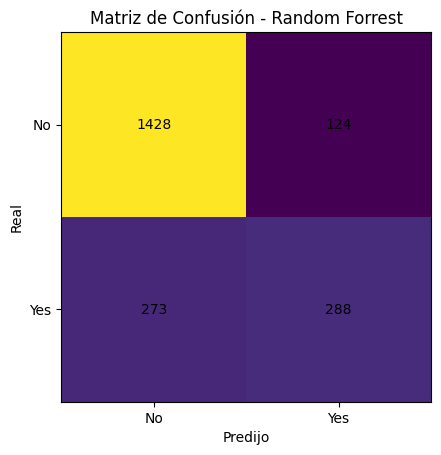

In [92]:
#  Para RANDOM FORREST
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusión - Random Forrest")
plt.xlabel("Predijo")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

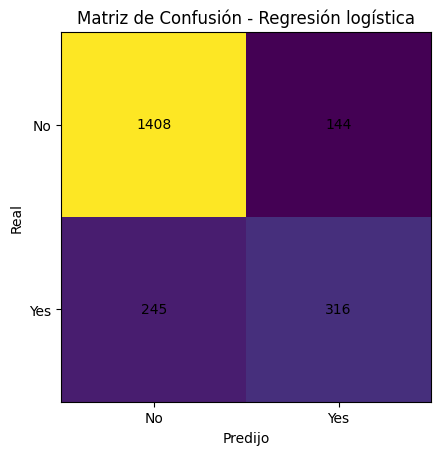

In [93]:
#  Para REGRESION LOGISTICA NORMAL
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusión - Regresión logística")
plt.xlabel("Predijo")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

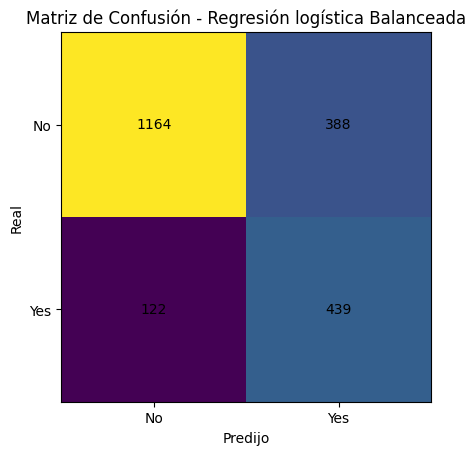

In [94]:
#  Para REGRESION LOGISTICA BALANCEADA
cm = confusion_matrix(y_test, y_pred_log_normal_bal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusión - Regresión logística Balanceada")
plt.xlabel("Predijo")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

---
#🎯Exportando el mejor modelo:🎯
---

In [95]:
#  Como el modelo Regresión Logística tuvo el mejor desempeño, los vamos a exportar
import pickle


In [96]:
#  Cargando el modelo guardado:
with open('modelo_champion.pkl', 'wb') as archivo:
    pickle.dump(log_model, archivo)

---
# 📝 INFORME FINAL
## TelecomX — Predicción de Evasión de Clientes · Parte 2
---
---


## Introducción

<p>La empresa Telecom X enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Esta evasión de clientes representa un problema relevante para el negocio, ya que impacta directamente en la estabilidad y en los ingresos. A través del análisis de datos, se busca generar información que sirva como base para futuras estrategias de retención y modelos predictivos.

El objetivo principal, utilizando Python y sus principales bibliotecas, se centra en predecir la cancelación de clientes en telecomunicaciones mediante análisis de datos y modelos de machine learning.

</p>


---

## Descripción del proyecto

Este proyecto tiene como objetivo analizar los factores asociados a la cancelación de clientes en una empresa de telecomunicaciones y desarrollar modelos de machine learning capaces de predecir qué clientes tienen mayor probabilidad de abandonar el servicio.

El análisis incluye etapas de exploración de datos, preparación, modelado predictivo e interpretación de resultados.

***



## Objetivos del proyecto

- Identificar los factores que influyen en la cancelación de clientes
- Preparar los datos para su uso en modelos de Machine Learning.
- Analizar el balance de clases y su impacto en el modelado.
- Entrenar y comparar distintos modelos de clasificación.
- Evaluar el desempeño mediante métricas apropiadas para problemas de churn.
- Interpretar la importancia de las variables más relevantes.
- Generar conclusiones y recomendaciones estratégicas basadas en los resultados.


**************************************


## Etapas del proyecto



## Preparación y preprocesamiento de datos

En esta etapa se realizaron las siguientes tareas:

- Carga del archivo tratado en la Parte 1 del proyecto.
- Eliminación de columnas irrelevantes para el modelado (identificadores).
- Codificación de variables categóricas mediante **One-Hot Encoding**.
- Separación de variables numéricas y categóricas utilizando `ColumnTransformer`.
- Análisis de la proporción de churn para detectar desbalance de clases.
- Normalización aplicada únicamente a los modelos sensibles a la escala.

---

## Modelado Predictivo

Se entrenaron cinco modelos:
- Baseline (DummyClassifier)
- Regresión Logística
- Árbol de Decisión
- Random Forest
- KNN

Los modelos fueron evaluados utilizando métricas estándar:
- Accuracy
- Precision
- Recall
- F1-score
- Matrices de confusión (valores absolutos y normalizados)

Se priorizaron métricas como **Recall** y **F1-score**, considerando el desbalance moderado de clases y la importancia de detectar clientes con riesgo de evasión.


---

## Resultados

El modelo de Regresión Logística balanceada presentó el mejor desempeño para este problema, destacándose especialmente en la detección de clientes en riesgo de cancelación (mayor recall).

Esto es especialmente relevante en problemas de churn, donde el objetivo principal es anticipar la cancelación y permitir acciones de retención.

---

## Importancia de las variables

A partir del modelo seleccionado (Regresión Logística), se analizó la contribución de las variables al proceso de predicción.

Los resultados indican que la evasión de clientes está principalmente asociada a:

- Baja antigüedad del cliente.
- Contratos de corto plazo.
- Determinadas configuraciones de servicios y cargos.

Por el contrario, una mayor permanencia y contratos de mayor duración actúan como factores protectores frente al churn.

---

## Principales hallazgos

El análisis permitió identificar factores clave asociados al churn:

Clientes con menor antigüedad presentan mayor riesgo de cancelación

Contratos mensuales muestran mayor tasa de abandono

Cargos mensuales elevados se asocian con mayor churn


---
---
## Conclusiones

El modelo de **Regresión Logística** presentó el mejor desempeño general, logrando un equilibrio adecuado entre precisión y capacidad de detección de clientes que cancelan.

El análisis confirma que la evasión de clientes no depende de un único factor, sino de la combinación de variables contractuales, económicas y de relación con el servicio. La utilización de modelos predictivos permite anticipar comportamientos de riesgo y orientar acciones preventivas basadas en datos.

---

## Recomendaciones estratégicas

- Implementar estrategias de retención temprana para clientes con baja antigüedad.
- Incentivar la migración hacia contratos de mayor duración.
- Priorizar acciones comerciales sobre clientes identificados como de alto riesgo.
- Integrar el modelo predictivo como sistema de alerta temprana dentro del negocio.

---
---